#  Amazon Sentiment Analysis

---

## What is Sentiment Analysis?

Sentiment analysis is the process of analyzing text to determine
if the emotional tone is positive, negative, or neutral.

It is also called **opinion mining**.

### Real world use cases:
- Customer service — understand mood of complaints
- Brand monitoring — track what people say about a company
- Market research — what features do customers love or hate
- Campaign tracking — is the ad response positive or negative

---

## Why it matters:

Traditional approach → humans read reviews manually
                     → slow, biased, not scalable

Sentiment Analysis  → AI reads thousands of reviews instantly
                     → objective, consistent, scalable

---

## Our Task:

Dataset  : Amazon Fine Food Reviews
Label    : Score (1-5 stars)
Features : Review Text

We convert 5 star ratings into binary sentiment:
- Score 1, 2  → Negative (0)
- Score 4, 5  → Positive (1)
- Score 3     → Dropped (neutral is ambiguous)

Goal: predict whether a review is Positive or Negative
based on the text alone.

In [116]:
from string import punctuation

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter
from textblob import TextBlob
from nltk.util import ngrams

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB,BernoulliNB,GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

from scipy.sparse import hstack,csr_matrix
import pickle

In [3]:
df = pd.read_csv('Reviews.csv')

In [4]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
df['Text'][0]

'I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.'

In [6]:
df.shape

(568454, 10)

In [7]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 43.4 MB


In [9]:
df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


In [10]:
df.isna().sum()

Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64

In [11]:
(df['Score'].value_counts()/df['Score'].value_counts().sum())*100

Score
5    63.878871
4    14.188483
1     9.194763
3     7.501047
2     5.236835
Name: count, dtype: float64

# Data Cleaning

In [12]:
indices_to_drop = df[df['Score']==3].index
df.drop(indices_to_drop,inplace=True)

In [13]:
df

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
...,...,...,...,...,...,...,...,...,...,...
568449,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
568450,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
568451,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
568452,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [14]:
df['Score'].value_counts()

Score
5    363122
4     80655
1     52268
2     29769
Name: count, dtype: int64

In [15]:
df.drop(columns=['Id','ProductId','UserId','ProfileName','HelpfulnessNumerator','HelpfulnessDenominator','Time'],inplace=True)

In [16]:
df.head()

,Score,Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...


In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 525814 entries, 0 to 568453
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   Score    525814 non-null  int64
 1   Summary  525789 non-null  str  
 2   Text     525814 non-null  str  
dtypes: int64(1), str(2)
memory usage: 16.0 MB


In [18]:
one_star_review = df[df['Score']==1]
two_star_review = df[df['Score']==2]
four_star_review = df[df['Score']==4]
five_star_review = df[df['Score']==5]

In [19]:
negative_reviews = pd.concat([one_star_review.sample(20000),two_star_review.sample(20000)])
positive_reviews = pd.concat([four_star_review.sample(20000),five_star_review.sample(20000)])

In [20]:
df = pd.concat([negative_reviews,positive_reviews]).reset_index(drop=True)
df.sample(10)

,Score,Summary,Text
11933,1,Gas Attack in a Can,Most of the Merrick 5 star varieties seem to g...
56893,4,what a great little invention,takes a lot of the mess out of the Natural PB ...
27834,2,Too pricey for too short a time,I was really excited to try these after hearin...
54387,4,"Good, if you can acquire the taste","I've gone back and forth on this cereal, which..."
9013,1,Don't buy if you want pumpkin flavor!!!!! Grea...,It's disgusting!! No pumpkin flavor at all!! I...
9957,1,Beware of artificial sweetener!,In two words...awful and artificial. I didn't...
44543,4,candy cigarettes,well i purchasethis gift for a friend who love...
69609,5,Super Yummy Gummies!!!,"Wow,what a great deal! These are SUPERIOR gumm..."
33809,2,Good but hardly any passion fruit flavor,I have two vines producing passion fruit in my...
41092,4,Pretty good,These granola bars are pretty good and healthy...


In [21]:
df['Score'] = df['Score'].map(
    {
        1:0
        ,2:0
        ,4:1
        ,5:1
    })

In [22]:
df

,Score,Summary,Text
0,0,Be careful! I found a metal button in the cho...,I recently bought scharffen berger chocolate f...
1,0,Disappointing,"Having read great reviews about this product, ..."
2,0,Terrible Tasting!!!!,"Paid 10.00 for this item, and another 10.00 fo..."
3,0,New Ovaltine - Please give me the original for...,What a disappointment it was to try the new Ne...
4,0,"Poor,",Flavor an texture are very poor. Was hoping t...
...,...,...,...
79995,1,This is the ONLY food my dog will eat,"I have had my chihuahua since he was a puppy, ..."
79996,1,Great for ailing senior cats,My Molly is 18 years old and has chronic renal...
79997,1,Simply the best,These are simply the most delicious cookies I'...
79998,1,Crunchies are the best,Great seller with fast shipping. My kids love...


In [23]:
df.shape

(80000, 3)

In [24]:
df['Score'].value_counts()

Score
0    40000
1    40000
Name: count, dtype: int64

In [25]:
df.isna().sum()

Score       0
Summary    17
Text        0
dtype: int64

In [26]:
df['review'] = df['Summary'].fillna('')+ ' '+ df['Text']

In [27]:
df

,Score,Summary,Text,review
0,0,Be careful! I found a metal button in the cho...,I recently bought scharffen berger chocolate f...,Be careful! I found a metal button in the cho...
1,0,Disappointing,"Having read great reviews about this product, ...",Disappointing Having read great reviews about ...
2,0,Terrible Tasting!!!!,"Paid 10.00 for this item, and another 10.00 fo...","Terrible Tasting!!!! Paid 10.00 for this item,..."
3,0,New Ovaltine - Please give me the original for...,What a disappointment it was to try the new Ne...,New Ovaltine - Please give me the original for...
4,0,"Poor,",Flavor an texture are very poor. Was hoping t...,"Poor, Flavor an texture are very poor. Was ho..."
...,...,...,...,...
79995,1,This is the ONLY food my dog will eat,"I have had my chihuahua since he was a puppy, ...",This is the ONLY food my dog will eat I have h...
79996,1,Great for ailing senior cats,My Molly is 18 years old and has chronic renal...,Great for ailing senior cats My Molly is 18 ye...
79997,1,Simply the best,These are simply the most delicious cookies I'...,Simply the best These are simply the most deli...
79998,1,Crunchies are the best,Great seller with fast shipping. My kids love...,Crunchies are the best Great seller with fast ...


In [28]:
df.drop(columns=['Summary','Text'],inplace=True)

In [29]:
df

,Score,review
0,0,Be careful! I found a metal button in the cho...
1,0,Disappointing Having read great reviews about ...
2,0,"Terrible Tasting!!!! Paid 10.00 for this item,..."
3,0,New Ovaltine - Please give me the original for...
4,0,"Poor, Flavor an texture are very poor. Was ho..."
...,...,...
79995,1,This is the ONLY food my dog will eat I have h...
79996,1,Great for ailing senior cats My Molly is 18 ye...
79997,1,Simply the best These are simply the most deli...
79998,1,Crunchies are the best Great seller with fast ...


In [30]:
print(df.shape)
print(df.columns)
print(df.head())

(80000, 2)
Index(['Score', 'review'], dtype='str')
   Score                                             review
0      0  Be careful!  I found a metal button in the cho...
1      0  Disappointing Having read great reviews about ...
2      0  Terrible Tasting!!!! Paid 10.00 for this item,...
3      0  New Ovaltine - Please give me the original for...
4      0  Poor, Flavor an texture are very poor.  Was ho...


# EDA

1> Does the positive or negative reviews which has a highest word count, sentence count, character count
2> Most repeated words in positive and negative reviews
3> Words that appear only in negative reviews but not in positive


In [31]:
df['char_length'] = df['review'].apply(len)

In [32]:
df

,Score,review,char_length
0,0,Be careful! I found a metal button in the cho...,523
1,0,Disappointing Having read great reviews about ...,231
2,0,"Terrible Tasting!!!! Paid 10.00 for this item,...",740
3,0,New Ovaltine - Please give me the original for...,426
4,0,"Poor, Flavor an texture are very poor. Was ho...",240
...,...,...,...
79995,1,This is the ONLY food my dog will eat I have h...,729
79996,1,Great for ailing senior cats My Molly is 18 ye...,663
79997,1,Simply the best These are simply the most deli...,241
79998,1,Crunchies are the best Great seller with fast ...,188


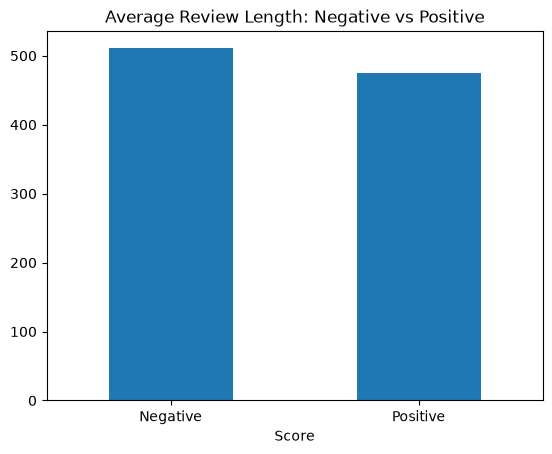

In [33]:
df.groupby('Score')['char_length'].mean().plot(kind='bar')
plt.title('Average Review Length: Negative vs Positive')
plt.xticks([0,1],['Negative','Positive'],rotation=0)
plt.show()

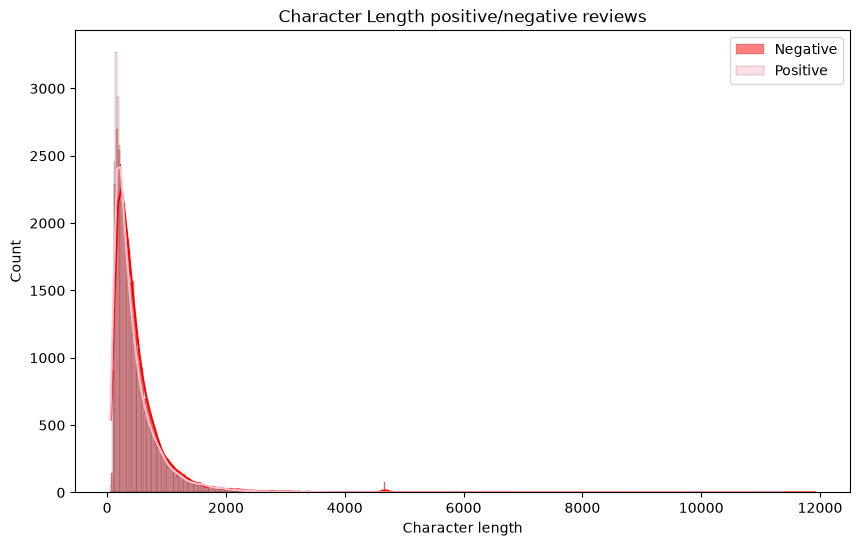

In [34]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['Score']==0]['char_length'],label='Negative',color='red',alpha = 0.5,kde=True)
sns.histplot(df[df['Score']==1]['char_length'],label='Positive',color='pink',alpha = 0.5,kde=True)
plt.title('Character Length positive/negative reviews')
plt.xlabel('Character length')
plt.legend()
plt.show()

from the plot above we can clearly see that negative reviews average CHARACTERS length is greater than positive reviews. Difference is not that big though only 37 characters. People write longer negative reviews
  likely explaining complaints in detail

In [35]:
df['word_count'] = df['review'].apply(lambda x: len(nltk.word_tokenize(x)))

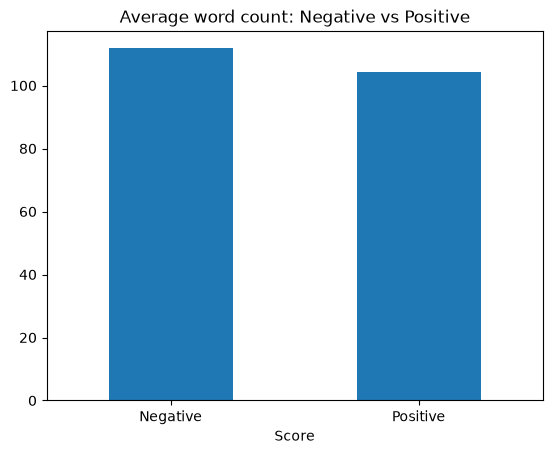

In [36]:
df.groupby('Score')['word_count'].mean().plot(kind='bar')
plt.title('Average word count: Negative vs Positive')
plt.xticks([0,1],['Negative','Positive'],rotation=0)
plt.show()

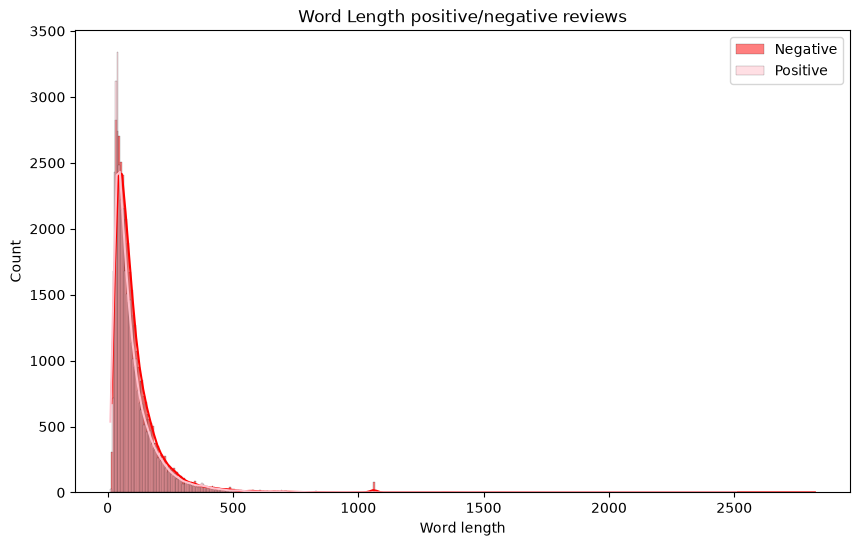

In [37]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['Score']==0]['word_count'],label='Negative',color='red',alpha = 0.5,kde=True)
sns.histplot(df[df['Score']==1]['word_count'],label='Positive',color='pink',alpha = 0.5,kde=True)
plt.title('Word Length positive/negative reviews')
plt.xlabel('Word length')
plt.legend()
plt.show()

## Word Count Analysis

- Negative reviews average ~111 words
- Positive reviews average ~104 words
- Only 7 word difference — very weak signal
- Consistent with length analysis (37 char difference)
- Confirms that engineered features (length, word count)
  will not be strong predictors here
- Sentiment lives in the words themselves, not the length

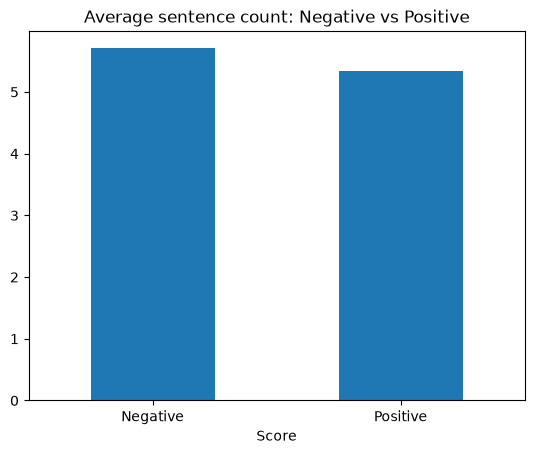

In [38]:
df['sentence_count'] = df['review'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.groupby('Score')['sentence_count'].mean().plot(kind='bar')
plt.title('Average sentence count: Negative vs Positive')
plt.xticks([0, 1], ['Negative', 'Positive'], rotation=0)
plt.show()

<Axes: >

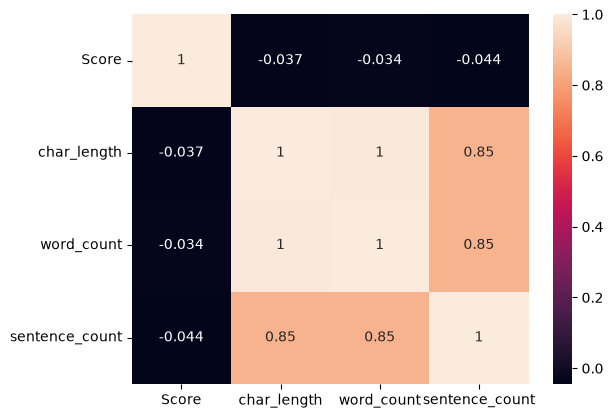

In [39]:
sns.heatmap(df[['Score','char_length','word_count','sentence_count']].corr(),annot=True)

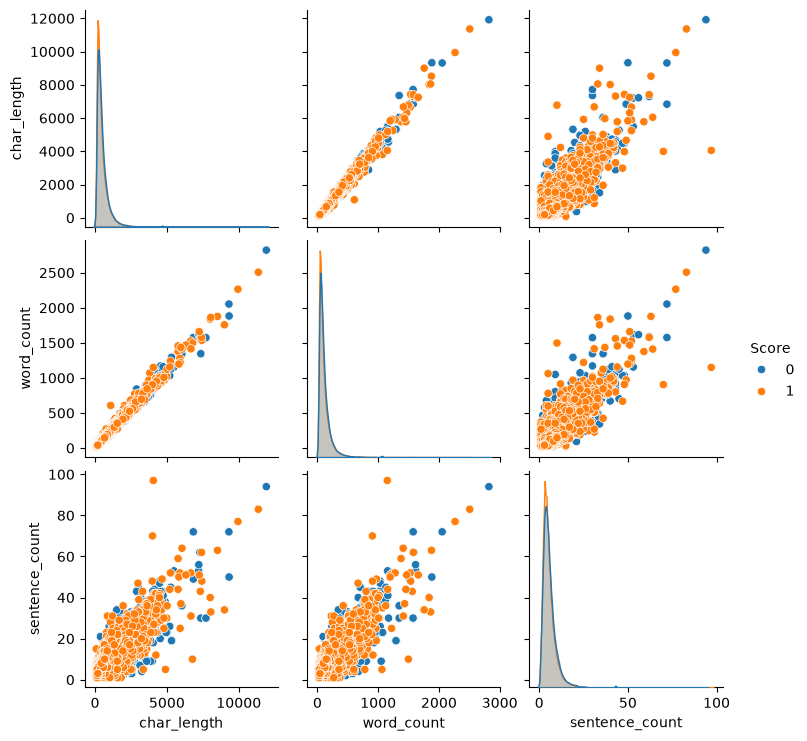

In [40]:
sns.pairplot(df[['char_length','word_count','sentence_count','Score']],hue='Score')

## Pairplot Observation

- Blue (negative) and orange (positive) dots are
  completely mixed in all scatter plots
- No visual separation between classes unlike spam project
- char_length vs word_count shows perfect diagonal line
  — confirms 1.0 correlation, completely redundant features
- sentence_count shows more spread — slightly more
  independent but still no class separation
- Confirms heatmap findings — length based features
  cannot discriminate sentiment

## Correlation Heatmap Observation

- char_length, word_count and sentence_count all show
  similar pattern — redundant to use all three features

- All three have near zero negative correlation with Score:
  char_length → -0.042
  word_count  → -0.039
  sentence_count → -0.048

- Negative correlation confirms — positive reviews (1)
  tend to be slightly shorter than negative reviews (0)

- char_length and word_count = 1.0 correlation —
  perfectly redundant, only need one of them


## Engineered Feature Analysis

All three length-based features show minimal difference
between positive and negative reviews:

- Characters : 509 vs 472  (8% difference)
- Words      : 111 vs 104  (6% difference)
- Sentences  : 5.7 vs 5.3  (7% difference)


- when i checked the word count, character count, and also sentence count found that there aint that much difference in them, Even in this hisplot both of them are completely overlaping, meaning hard to find the signal.

# -> Text Preprocessing

## lower, remove special character/ punctuation, remove stop words, lemmatization
### This is a real NLP problem called negation handling:
- "not good"    → removes "not" → "good"    ← model thinks positive! ❌
- "not bad"     → removes "not" → "bad"     ← model thinks negative! ❌
- "never again" → removes "never" → "again" ← loses meaning ❌

In [41]:
lemm = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))- {"not", "no", "never", "neither", "nor",
"hardly", "barely", "scarcely", "n't"}

contraction_fragments = {"wo", "ca", "sha","br"}

stop_words = stop_words | contraction_fragments

In [42]:
def text_preprocess(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalpha() or i == "n't":
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stop_words and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        lem_words = lemm.lemmatize(i)
        y.append(lem_words)

    return " ".join(y)

In [43]:
df['final_review'] = df['review'].apply(text_preprocess)

In [44]:
df.sample(5)

,Score,review,char_length,word_count,sentence_count,final_review
68340,1,THE BEST RICE! We have a favorite sushi restau...,865,195,9,best rice favorite sushi restaurant serve stic...
73917,1,black beluga lentils I have hunted high and lo...,297,61,6,black beluga lentil hunted high low find wonde...
18132,0,Nothing but 3 forms of SUGAR ! HELP.. I am con...,1177,322,12,nothing form sugar help confused advertise saf...
39085,0,Not So Good.. I really wanted to like this fla...,486,102,6,not good really wanted like flavor not good sm...
22560,0,"Seattle's Best Level 4 Sorry, I have tasted th...",203,44,3,seattle best level sorry tasted many seattle b...


In [45]:
sample = "This product didn't work and  I won't buy again. Not good at all!"
print(text_preprocess(sample))

product n't work n't buy not good


In [46]:
df['final_review'].isna().sum()

np.int64(0)

In [47]:
df[df['Score']==0]['final_review'].iloc[0]

'careful found metal button chocolate recently bought scharffen berger chocolate store near house tasted yummy however sampling almost broke tooth metal button chocolate hard get hold tell problem find something want get away fast give small amount money didnt like handled customer service really unsatisfying dont bother careful'

In [48]:
df[df['Score']==1]['final_review'].iloc[0]

"finally something son agree snackwise old constantly butting head healthier snack live cooky try least get fruit love mango container pretty much ate one snack agree also love banana kind sweet prefers n't tried new packaging one thing n't like old packaging n't refrigerate freeze dried fruit would soften get stuck together wonder new packaging"

In [49]:
print(df['review'].apply(len).mean())
print(df['final_review'].apply(len).mean())

492.7812875
289.8578375


## Text Preprocessing Results
- Average length before: 490 characters
- Average length after:  292 characters
- Doing this text processing we removed 40% of the noise like stop words or punctuation all that.
- Negation words preserved (not, never, n't) to maintain sentiment meaning

In [50]:
wc = WordCloud(
    height = 500,
    width = 500,
    background_color = 'white',
    min_font_size = 10
)

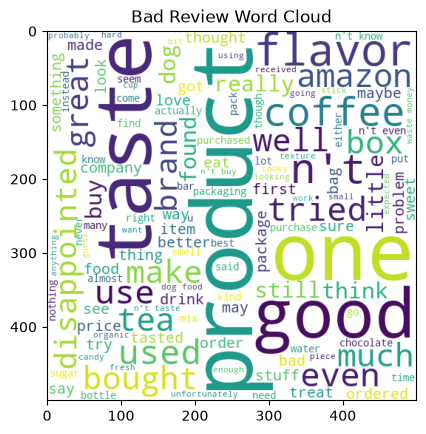

In [51]:
bad_reviews = wc.generate((df[df['Score']==0]['final_review']).str.cat(sep=" "))
plt.title("Bad Review Word Cloud")
plt.imshow(bad_reviews)

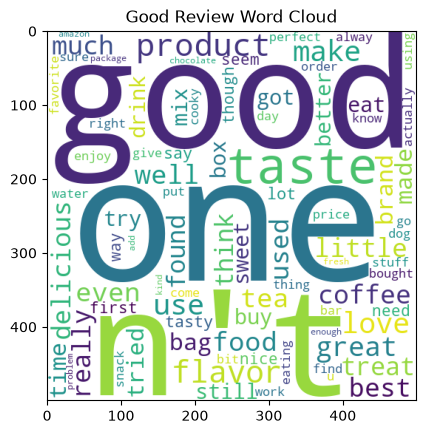

In [52]:
good_review = wc.generate((df[df['Score']==1]['final_review']).str.cat(sep=" "))
plt.title("Good Review Word Cloud")
plt.imshow(good_review)

## Wordcloud Analysis

Positive reviews: "love", "great", "delicious",
                  "flavor", "taste" dominate

Negative reviews: "bad", "disappointed", "taste",
                  "flavor" dominate

Common to both: "taste", "flavor", "coffee", "product"
→ these are food domain words, not sentiment words
→ TF-IDF will downweight them automatically

Issue found: "br" HTML artifact appears in both clouds
→ added to stopwords and reprocessed

In [53]:
word_list_good = []
for message in df[df['Score']==1]['final_review'].tolist():
    for text in message.split():
        word_list_good.append(text)

In [54]:
top_30_good = pd.DataFrame(Counter(word_list_good).most_common(30),columns = ['Words','Count'])

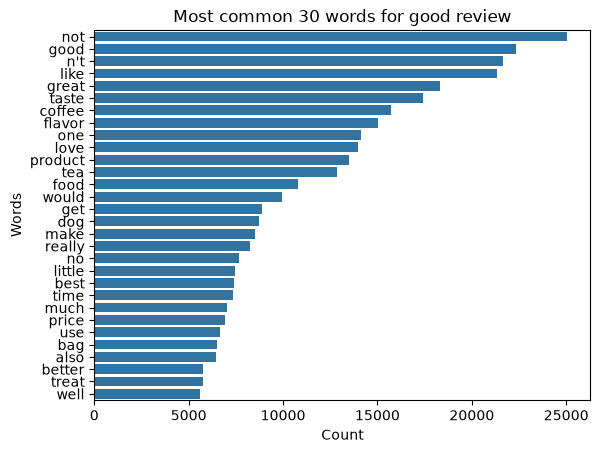

In [55]:
sns.barplot(data = top_30_good, x='Count',y='Words')
plt.title('Most common 30 words for good review')
plt.show()

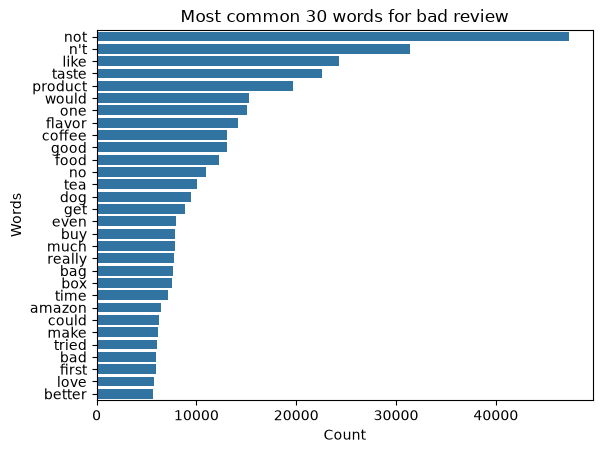

In [56]:
word_list_bad = []
for message in df[df['Score'] == 0]['final_review'].tolist():
    for text in message.split():
        word_list_bad.append(text)
top_30_bad = pd.DataFrame(Counter(word_list_bad).most_common(30), columns=['Words', 'Count'])
sns.barplot(data=top_30_bad, x='Count', y='Words')
plt.title('Most common 30 words for bad review')
plt.show()

## Most Common Words Analysis

- Both positive and negative reviews share similar
  high frequency words (taste, flavor, coffee, product)
  → food domain words dominate both classes

- Sentiment signal comes from adjectives:
  Positive → "great", "love", "best", "better"
  Negative → "bad", "disappointed", "waste"

### Here we check the polarity for each class, showing how positive or negative they are and also the Subjectivity which is if that's factual or opinion based...

In [57]:
df['polarity'] = df['final_review'].apply(lambda x: TextBlob(x).sentiment.polarity)

In [58]:
df['subjectivity'] = df['final_review'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

In [59]:
df

,Score,review,char_length,word_count,sentence_count,final_review,polarity,subjectivity
0,0,Be careful! I found a metal button in the cho...,523,109,10,careful found metal button chocolate recently ...,-0.030208,0.548958
1,0,Disappointing Having read great reviews about ...,231,44,3,disappointing read great review product purcha...,0.140000,0.630000
2,0,"Terrible Tasting!!!! Paid 10.00 for this item,...",740,173,16,terrible tasting paid item another shipping kn...,-0.072727,0.556061
3,0,New Ovaltine - Please give me the original for...,426,89,6,new ovaltine please give original formula disa...,0.099184,0.658392
4,0,"Poor, Flavor an texture are very poor. Was ho...",240,48,3,poor flavor texture poor hoping whole wheat pr...,0.016667,0.512821
...,...,...,...,...,...,...,...,...
79995,1,This is the ONLY food my dog will eat I have h...,729,166,10,food dog eat chihuahua since puppy never much ...,0.094048,0.557143
79996,1,Great for ailing senior cats My Molly is 18 ye...,663,146,10,great ailing senior cat molly year old chronic...,0.028939,0.480152
79997,1,Simply the best These are simply the most deli...,241,56,3,simply best simply delicious cooky ever tasted...,0.360185,0.522222
79998,1,Crunchies are the best Great seller with fast ...,188,41,3,crunchies best great seller fast shipping kid ...,0.416071,0.607143


In [60]:
df.groupby('Score')['polarity'].mean()

Score
0    0.014065
1    0.299006
Name: polarity, dtype: float64

In [61]:
df.groupby('Score')['subjectivity'].mean()

Score
0    0.523853
1    0.565738
Name: subjectivity, dtype: float64

## Polarity Analysis (TextBlob)

- Positive reviews: mean polarity 0.301 → clearly positive
- Negative reviews: mean polarity 0.012 → near neutral

- Negative reviews score near zero not negative because:
  reviewers use mixed language — describe what was
  good before explaining what went wrong

- Subjectivity similar for both (0.52 vs 0.57) —
  both classes are opinion based as expected

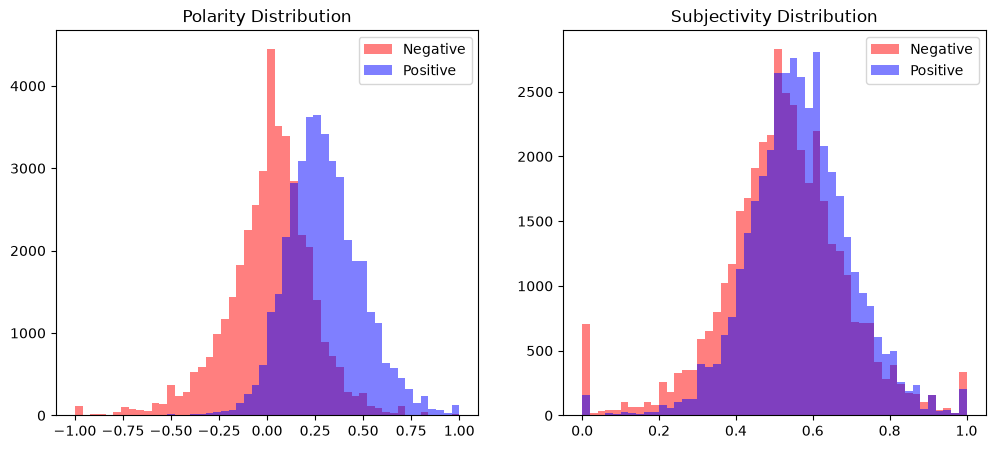

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# polarity distribution
axes[0].hist(df[df['Score']==0]['polarity'],
             alpha=0.5, label='Negative', color='red', bins=50)
axes[0].hist(df[df['Score']==1]['polarity'],
             alpha=0.5, label='Positive', color='blue', bins=50)
axes[0].set_title('Polarity Distribution')
axes[0].legend()

# subjectivity distribution
axes[1].hist(df[df['Score']==0]['subjectivity'],
             alpha=0.5, label='Negative', color='red', bins=50)
axes[1].hist(df[df['Score']==1]['subjectivity'],
             alpha=0.5, label='Positive', color='blue', bins=50)
axes[1].set_title('Subjectivity Distribution')
axes[1].legend()

plt.show()

## Polarity & Subjectivity Distribution

Polarity:
- Negative reviews peak near 0.0
- Positive reviews peak near 0.25-0.30
- Some separation exists but large overlap zone
- Rule based polarity partially useful but not reliable alone

Subjectivity:
- Both classes almost identical distribution
- Peak around 0.5 for both
- Completely useless as discriminating feature
- Both reviews are equally opinion based

In [63]:
positive_corpus = " ".join(df[df['Score']==1]['final_review']).split()
positive_bigram = ngrams(positive_corpus,2)
print(Counter(positive_bigram).most_common(10))
positive_trigram = ngrams(positive_corpus,3)
print(Counter(positive_trigram).most_common(10))

[(('taste', 'like'), 1791), (('taste', 'great'), 1385), (('taste', 'good'), 1333), (('great', 'product'), 1329), (('dog', 'love'), 1301), (('pretty', 'good'), 1199), (('dog', 'food'), 1192), (('green', 'tea'), 1150), (('peanut', 'butter'), 1054), (('grocery', 'store'), 1052)]
[(('local', 'grocery', 'store'), 265), (('health', 'food', 'store'), 160), (('go', 'long', 'way'), 160), (('could', "n't", 'find'), 159), (('would', 'highly', 'recommend'), 142), (('green', 'mountain', 'coffee'), 140), (('great', 'product', 'great'), 137), (("n't", 'go', 'wrong'), 135), (('taste', 'pretty', 'good'), 129), (('highly', 'recommend', 'product'), 126)]


In [64]:
negative_corpus = " ".join(df[df['Score']==0]['final_review']).split()
negative_bigram = ngrams(negative_corpus,2)
print(Counter(negative_bigram).most_common(10))

negative_trigram = ngrams(negative_corpus,3)
print(Counter(negative_trigram).most_common(10))

[(('taste', 'like'), 3884), (('not', 'good'), 2385), (('would', 'not'), 2027), (('would', "n't"), 1684), (("n't", 'like'), 1681), (('not', 'buy'), 1566), (('could', "n't"), 1501), (("n't", 'know'), 1404), (("n't", 'even'), 1306), (("n't", 'taste'), 1192)]
[(('would', 'not', 'recommend'), 532), (("n't", 'waste', 'money'), 386), (("n't", 'taste', 'like'), 376), (('would', 'not', 'buy'), 366), (('not', 'taste', 'like'), 256), (('local', 'grocery', 'store'), 246), (('high', 'fructose', 'corn'), 235), (('not', 'worth', 'money'), 232), (('fructose', 'corn', 'syrup'), 229), (('not', 'buy', 'product'), 221)]


In [65]:
df

,Score,review,char_length,word_count,sentence_count,final_review,polarity,subjectivity
0,0,Be careful! I found a metal button in the cho...,523,109,10,careful found metal button chocolate recently ...,-0.030208,0.548958
1,0,Disappointing Having read great reviews about ...,231,44,3,disappointing read great review product purcha...,0.140000,0.630000
2,0,"Terrible Tasting!!!! Paid 10.00 for this item,...",740,173,16,terrible tasting paid item another shipping kn...,-0.072727,0.556061
3,0,New Ovaltine - Please give me the original for...,426,89,6,new ovaltine please give original formula disa...,0.099184,0.658392
4,0,"Poor, Flavor an texture are very poor. Was ho...",240,48,3,poor flavor texture poor hoping whole wheat pr...,0.016667,0.512821
...,...,...,...,...,...,...,...,...
79995,1,This is the ONLY food my dog will eat I have h...,729,166,10,food dog eat chihuahua since puppy never much ...,0.094048,0.557143
79996,1,Great for ailing senior cats My Molly is 18 ye...,663,146,10,great ailing senior cat molly year old chronic...,0.028939,0.480152
79997,1,Simply the best These are simply the most deli...,241,56,3,simply best simply delicious cooky ever tasted...,0.360185,0.522222
79998,1,Crunchies are the best Great seller with fast ...,188,41,3,crunchies best great seller fast shipping kid ...,0.416071,0.607143


### Feature Extraction

In [66]:
final_df = df[['Score','final_review']]

In [67]:
final_df

,Score,final_review
0,0,careful found metal button chocolate recently ...
1,0,disappointing read great review product purcha...
2,0,terrible tasting paid item another shipping kn...
3,0,new ovaltine please give original formula disa...
4,0,poor flavor texture poor hoping whole wheat pr...
...,...,...
79995,1,food dog eat chihuahua since puppy never much ...
79996,1,great ailing senior cat molly year old chronic...
79997,1,simply best simply delicious cooky ever tasted...
79998,1,crunchies best great seller fast shipping kid ...


In [68]:
X = final_df['final_review']
y = final_df['Score']

### Train_Test_Split

In [69]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

### TF-IDF Vectorization

In [70]:
tfidf = TfidfVectorizer()
X_train_tf = tfidf.fit_transform(X_train)
X_test_tf = tfidf.transform(X_test)

In [71]:
print(X_train_tf.shape)
print(X_test_tf.shape)

(60000, 37988)
(20000, 37988)


### Model Building

In [72]:
models = {
    'Multinomial NB': MultinomialNB(),
    'Bernoulli NB': BernoulliNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=50,random_state=42),
    'XGBoost': XGBClassifier(n_estimators=50,random_state=42),
    'SVM': SVC(kernel='linear')
}

In [73]:
results = []
trained_models = {}
def train_and_test(train_x,test_x,train_y,test_y):
    for name, model in models.items():
        model.fit(train_x,train_y)
        y_pred = model.predict(test_x)
        accuracy = accuracy_score(test_y,y_pred)
        precision = precision_score(test_y,y_pred)

        results.append([name,accuracy,precision])
        trained_models[name] = model

results_df = pd.DataFrame(results,columns=['Model','Accuracy','Precision'])

In [74]:
train_and_test(X_train_tf,X_test_tf,y_train,y_test)

In [75]:
results

[['Multinomial NB', 0.8632, 0.8559363645291171],
 ['Bernoulli NB', 0.85105, 0.8249536178107607],
 ['Logistic Regression', 0.8921, 0.8935143288084465],
 ['Random Forest', 0.8899, 0.8927237864567564],
 ['XGBoost', 0.85095, 0.8567644661776691],
 ['SVM', 0.8952, 0.8970306995470558]]

In [76]:
trained_models

{'Multinomial NB': MultinomialNB(),
 'Bernoulli NB': BernoulliNB(),
 'Logistic Regression': LogisticRegression(max_iter=1000),
 'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_estimators=50,
               n_jobs=None, num_parallel_tree=None, ...),
 'SVM': SVC(kern

## Adding polarity as well to check if we can get better result and we only used our top 3 models......

In [77]:
final_df

,Score,final_review
0,0,careful found metal button chocolate recently ...
1,0,disappointing read great review product purcha...
2,0,terrible tasting paid item another shipping kn...
3,0,new ovaltine please give original formula disa...
4,0,poor flavor texture poor hoping whole wheat pr...
...,...,...
79995,1,food dog eat chihuahua since puppy never much ...
79996,1,great ailing senior cat molly year old chronic...
79997,1,simply best simply delicious cooky ever tasted...
79998,1,crunchies best great seller fast shipping kid ...


In [78]:
polarity_train = df.loc[X_train.index,'polarity']

,Score,review,char_length,word_count,sentence_count,final_review,polarity,subjectivity
0,0,Be careful! I found a metal button in the cho...,523,109,10,careful found metal button chocolate recently ...,-0.030208,0.548958
1,0,Disappointing Having read great reviews about ...,231,44,3,disappointing read great review product purcha...,0.140000,0.630000
2,0,"Terrible Tasting!!!! Paid 10.00 for this item,...",740,173,16,terrible tasting paid item another shipping kn...,-0.072727,0.556061
3,0,New Ovaltine - Please give me the original for...,426,89,6,new ovaltine please give original formula disa...,0.099184,0.658392
4,0,"Poor, Flavor an texture are very poor. Was ho...",240,48,3,poor flavor texture poor hoping whole wheat pr...,0.016667,0.512821
...,...,...,...,...,...,...,...,...
79995,1,This is the ONLY food my dog will eat I have h...,729,166,10,food dog eat chihuahua since puppy never much ...,0.094048,0.557143
79996,1,Great for ailing senior cats My Molly is 18 ye...,663,146,10,great ailing senior cat molly year old chronic...,0.028939,0.480152
79997,1,Simply the best These are simply the most deli...,241,56,3,simply best simply delicious cooky ever tasted...,0.360185,0.522222
79998,1,Crunchies are the best Great seller with fast ...,188,41,3,crunchies best great seller fast shipping kid ...,0.416071,0.607143


In [93]:
polarity_train = df.loc[X_train.index,'polarity'].values.reshape(-1,1)
polarity_test = df.loc[X_test.index,'polarity'].values.reshape(-1,1)

polarity_train_sparse = csr_matrix(polarity_train)
polarity_test_sparse = csr_matrix(polarity_test)

X_train_combined = hstack([X_train_tf,polarity_train_sparse])
X_test_combined = hstack([X_test_tf,polarity_test_sparse])

In [94]:
print(X_train_combined.shape)
print(X_test_combined.shape)

(60000, 37989)
(20000, 37989)


In [97]:
models_polarity = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=50,random_state=42),
    'SVM': SVC(kernel='linear')
}

In [98]:
results_polarity = []
trained_models_polarity = {}
def train_and_test(train_x,test_x,train_y,test_y):
    for name, model in models_polarity.items():
        model.fit(train_x,train_y)
        y_pred = model.predict(test_x)
        accuracy = accuracy_score(test_y,y_pred)
        precision = precision_score(test_y,y_pred)

        results_polarity.append([name,accuracy,precision])
        trained_models_polarity[name] = model

In [101]:
train_and_test(X_train_combined, X_test_combined, y_train, y_test)

In [102]:
results_df_polarity = pd.DataFrame(results_polarity,columns=['Model','Accuracy','Precision'])
results_df_polarity

,Model,Accuracy,Precision
0,Logistic Regression,0.89225,0.891813
1,Random Forest,0.88985,0.892951
2,Logistic Regression,0.89225,0.891813
3,Random Forest,0.88985,0.892951
4,SVM,0.89825,0.898376


## TF-IDF vs TF-IDF + Polarity

Adding TextBlob polarity score did not improve results.
TF-IDF already captures sentiment signal through word weights.
Polarity adds redundant information — confirmed by minimal
or negative impact on accuracy and precision.

Best model remains: SVM + TF-IDF (89.8% accuracy, 90.4% precision)

In [106]:
tfidf_optimize = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df = 2,
    max_df = 0.95
)

In [107]:
X_train

75231    delicious not good plenty sweet chewy licorice...
60018    great treat great price picked bag petco first...
13958    taste ok first not sure hype like certain frui...
75132    flavorful delicious without extra calorie cost...
13839    messy arrival looking forward receiving item e...
                               ...                        
6265     contains splenda yuck product description clai...
54886    n't hammer nail screwdriver well actually resu...
76820    pounce moist caribbean cat love love tuna actu...
860      delightfully dented every single soup order de...
15795    dishonest advertising not decaf although title...
Name: final_review, Length: 60000, dtype: str

In [108]:
X_train_tf_optimize = tfidf_optimize.fit_transform(X_train)
X_test_tf_optimize = tfidf_optimize.transform(X_test)

In [109]:
print(X_train_tf_optimize.shape)
print(X_test_tf_optimize.shape)

(60000, 50000)
(20000, 50000)


In [110]:
models_tf_optimize = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=50,random_state=42),
    'SVM': SVC(kernel='linear')
}

In [111]:
results_tf_optimize = []
trained_models_tf_optimize = {}


def train_and_test(train_x, test_x, train_y, test_y):
    for name, model in models_tf_optimize.items():
        model.fit(train_x, train_y)
        y_pred = model.predict(test_x)
        accuracy = accuracy_score(test_y, y_pred)
        precision = precision_score(test_y, y_pred)

        results_tf_optimize.append([name, accuracy, precision])
        trained_models_tf_optimize[name] = model


train_and_test(X_train_tf_optimize, X_test_tf_optimize, y_train, y_test)
results_df_tf_optimize = pd.DataFrame(results_tf_optimize, columns=['Model', 'Accuracy', 'Precision'])
results_df_tf_optimize

,Model,Accuracy,Precision
0,Logistic Regression,0.91115,0.912877
1,Random Forest,0.89940,0.901986
2,SVM,0.92110,0.921742


In [ ]:
trained_models_tf_optimize

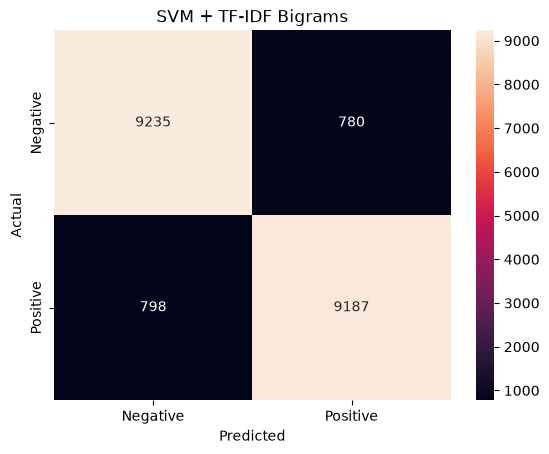

In [115]:
y_pred_final = trained_models_tf_optimize['SVM'].predict(X_test_tf_optimize)
sns.heatmap(confusion_matrix(y_test,y_pred_final),annot=True,fmt='d',xticklabels=['Negative','Positive'],yticklabels=['Negative','Positive'])
plt.title('SVM + TF-IDF Bigrams')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Final Model — SVM + TF-IDF Bigrams

Confusion Matrix:
- Correctly classified 9235 negative reviews
- Correctly classified 9187 positive reviews
- 780 false positives, 798 false negatives
- Almost equal errors in both directions
  → balanced sampling strategy paid off
- Final accuracy: 92.1%, Precision: 92.2%

### The best Model saved using pickle

In [117]:
with open('model.pkl','wb') as f:
    pickle.dump(trained_models_tf_optimize['SVM'],f)

In [118]:
with open('vectorizer.pkl','wb') as f:
    pickle.dump(tfidf_optimize,f)

In [125]:
model = pickle.load(open('model.pkl','rb'))
vectorizer = pickle.load(open('vectorizer.pkl','rb'))
sample = """Not the cheapest option out there but
absolutely worth every penny.
Would highly recommend to anyone
looking for quality."""
vector = vectorizer.transform([sample])
result = model.predict(vector)

In [126]:
print("Negative" if result[0]==0 else "positive")

positive
